In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sea

In [2]:
df = pd.read_csv(r"C:\Users\windows 10\Downloads\archive (3)\Reviews.csv")

In [3]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
df.shape

(568454, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [6]:
df.isna().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

# Data Cleaning:-

In [7]:
df = df[['Score' , 'Text']]

In [8]:
df.isna().sum()

Score    0
Text     0
dtype: int64

In [9]:
df.head(2)

,Score,Text
0,5,I have bought several of the Vitality canned d...
1,1,Product arrived labeled as Jumbo Salted Peanut...


In [10]:
print('The comment of first person and ')
print('Rating of the person:- ', df['Score'].iloc[0])
df['Text'].iloc[0]

The comment of first person and 
Rating of the person:-  5


'I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.'

In [11]:
df['Text'].iloc[1]

'Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".'

# Rating Destribution:-

In [12]:
Score_dis = df['Score'].value_counts().sort_index()

In [13]:
Score_dis

Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64

In [14]:
print('PERCENTAGES\n')
for score , count in Score_dis.items():
    per = (count/len(df)) * 100
    print(f'{score} stars :- { per:.2f}%')

PERCENTAGES

1 stars :- 9.19%
2 stars :- 5.24%
3 stars :- 7.50%
4 stars :- 14.19%
5 stars :- 63.88%


In [15]:
for score in [1,2,3,4,5]:
    simple_rev = df[df['Score'] == score]['Text'].iloc[0]
    print(f'\n⭐  {score}-review')
    print(f'{simple_rev}\n')
    


⭐  1-review
Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".


⭐  2-review
If you are looking for the secret ingredient in Robitussin I believe I have found it.  I got this in addition to the Root Beer Extract I ordered (which was good) and made some cherry soda.  The flavor is very medicinal.


⭐  3-review
This seems a little more wholesome than some of the supermarket brands, but it is somewhat mushy and doesn't have quite as much flavor either.  It didn't pass muster with my kids, so I probably won't buy it again.


⭐  4-review
This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then liberally coated with powdered sugar.  And it is a tiny mouthful of heaven.  Not too chewy, and very flavorful.  I highly recommend this yummy tre

# Data Visualisation:-

In [16]:
df['text_length'] = df['Text'].str.len()
df['word_count'] = df['Text'].str.split().str.len()

In [17]:
df.head()

,Score,Text,text_length,word_count
0,5,I have bought several of the Vitality canned d...,263,48
1,1,Product arrived labeled as Jumbo Salted Peanut...,190,31
2,4,This is a confection that has been around a fe...,509,94
3,2,If you are looking for the secret ingredient i...,219,41
4,5,Great taffy at a great price. There was a wid...,140,27


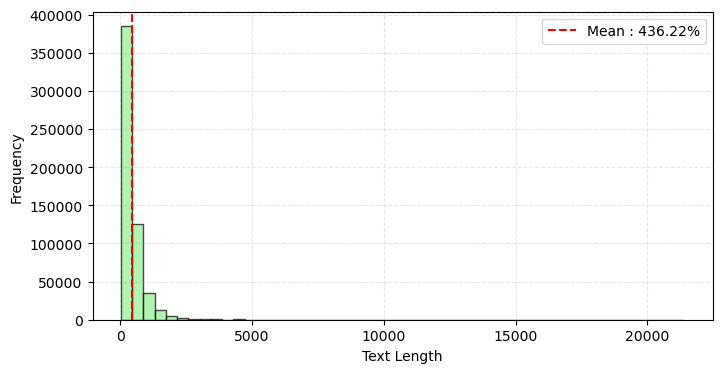

In [18]:
plt.figure(figsize = (8,4))
plt.hist(df['text_length'] , bins = 50, alpha = 0.7 , color = 'lightgreen', edgecolor = 'black')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.axvline(df['text_length'].mean(),color = 'red', linestyle = '--',
           label= f'Mean : {df['text_length'].mean():.2f}%')
plt.grid(alpha = 0.3, linestyle = '--')
plt.legend()

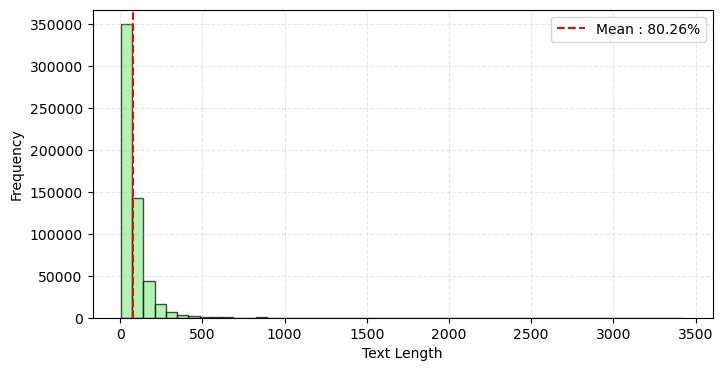

In [19]:
plt.figure(figsize = (8,4))
plt.hist(df['word_count'] , bins = 50, alpha = 0.7 , color = 'lightgreen', edgecolor = 'black')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.axvline(df['word_count'].mean(),color = 'red', linestyle = '--',
           label= f'Mean : {df['word_count'].mean():.2f}%')
plt.grid(alpha = 0.3, linestyle = '--')
plt.legend()

In [20]:
df.head(3)

,Score,Text,text_length,word_count
0,5,I have bought several of the Vitality canned d...,263,48
1,1,Product arrived labeled as Jumbo Salted Peanut...,190,31
2,4,This is a confection that has been around a fe...,509,94


We will take only 1&2 ratings as bad and 4&5 ratings as good, the 3 is the most confusing one.

In [21]:
df_binary = df[df['Score'] != 3].copy()
df_binary['sentiment'] = (df_binary['Score'] >= 4).astype(int)

In [22]:
df_binary.head(2)

,Score,Text,text_length,word_count,sentiment
0,5,I have bought several of the Vitality canned d...,263,48,1
1,1,Product arrived labeled as Jumbo Salted Peanut...,190,31,0


In [23]:
df_binary['Score'].value_counts()

Score
5    363122
4     80655
1     52268
2     29769
Name: count, dtype: int64

The Three Star Revius Are Removed.

In [24]:
print(f"The Negative revies (1 - 2) :- {sum(df_binary['sentiment'] == 0):,}")

The Negative revies (1 - 2) :- 82,037


In [25]:
print(f"The Positive revies (4 - 5) :- {sum(df_binary['sentiment'] == 1):,}")

The Positive revies (4 - 5) :- 443,777


In [26]:
print(df_binary[df_binary['sentiment'] == 0].value_counts())

Score  Text                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [27]:
df_binary['sentiment'].value_counts()

sentiment
1    443777
0     82037
Name: count, dtype: int64

In [28]:
df_binary['sentiment'].value_counts().iloc[1]

np.int64(82037)

The class imbalence:-

In [29]:
neg_rev = (sum(df_binary['sentiment'] == 0) / len(df_binary)) * 100
pos_rev = (sum(df_binary['sentiment'] == 1) / len(df_binary)) * 100
print('Positive Reviews:- ', pos_rev)
print('Negative Reviews:- ' , neg_rev)

Positive Reviews:-  84.3980951439102
Negative Reviews:-  15.601904856089796


# Handle Class Imbalence:-

In [30]:
from sklearn.utils import resample

In [31]:
negative_reviews = df_binary[df_binary['sentiment'] == 0]
positive_reviews = df_binary[df_binary['sentiment'] == 1]

In [32]:
n_minority = len(negative_reviews)
positive_downsampled = resample(positive_reviews , replace = False , n_samples = n_minority)

In [33]:
positive_downsampled

,Score,Text,text_length,word_count,sentiment
210273,5,The cats couldn't lick their paws enough after...,176,33,1
307052,5,The Jalapeno Smokehouse almonds taste great an...,207,38,1
330928,5,This is the best gluten free pizza crust that ...,218,45,1
210589,5,"I LOVE this stuff!!! Unfortunately, I can no ...",170,31,1
267111,4,"These graham crackers may not be for everyone,...",455,84,1
...,...,...,...,...,...
326231,5,i read about this tuna in Cook's Illustrated. ...,139,28,1
410674,5,Everyone in my house is addicted to this tea. ...,337,64,1
10043,5,There is a reason they serve this coffee at th...,197,35,1
159482,4,This is the sweetest Torani syrup I have ever ...,249,47,1


In [34]:
df_balenced = pd.concat([negative_reviews ,positive_downsampled])

In [35]:
df_balenced.info()

<class 'pandas.core.frame.DataFrame'>
Index: 164074 entries, 1 to 476482
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Score        164074 non-null  int64 
 1   Text         164074 non-null  object
 2   text_length  164074 non-null  int64 
 3   word_count   164074 non-null  int64 
 4   sentiment    164074 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 7.5+ MB


In [36]:
df_balenced.head(10)

,Score,Text,text_length,word_count,sentiment
1,1,Product arrived labeled as Jumbo Salted Peanut...,190,31,0
3,2,If you are looking for the secret ingredient i...,219,41,0
12,1,My cats have been happily eating Felidae Plati...,399,79,0
16,2,I love eating them and they are good for watch...,195,42,0
26,1,"The candy is just red , No flavor . Just plan...",88,20,0
50,1,"This oatmeal is not good. Its mushy, soft, I d...",89,19,0
62,1,Arrived in 6 days and were so stale i could no...,71,17,0
67,2,"I purchased the Mango flavor, and to me it doe...",479,87,0
73,1,Buyer Beware Please! This sweetener is not for...,1746,306,0
74,2,It is okay. I would not go out of my way to b...,57,15,0


We Need To Shuffle the data and adjust the index values:-

In [37]:
df_balenced = df_balenced.sample(frac = 1).reset_index(drop = True)

In [38]:
df_balenced.head()

,Score,Text,text_length,word_count,sentiment
0,1,I am afraid this tea does not have flavor of E...,207,42,0
1,2,"I have a shep/akita mix, but I bought this mor...",1119,222,0
2,5,I got hooked on these after flying and finally...,158,30,1
3,5,My Greater Swiss Mountain Dog didn't know what...,238,45,1
4,5,My Shih Tzus & Pekinese loved them - I only w...,151,29,1


In [39]:
neg_rev = (sum(df_balenced['sentiment'] == 0) / len(df_balenced)) * 100
pos_rev = (sum(df_balenced['sentiment'] == 1) / len(df_balenced)) * 100
print('Positive Reviews:- ', pos_rev)
print('Negative Reviews:- ' , neg_rev)

Positive Reviews:-  50.0
Negative Reviews:-  50.0


As The Data Set Size is heavy. If we perform An RNN The Traing Time will be high so Reducing the Data Points to Even more small.

In [40]:
sample_size = 25000
df_sample = df_balenced.sample(n = sample_size)

In [41]:
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 8940 to 87928
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Score        25000 non-null  int64 
 1   Text         25000 non-null  object
 2   text_length  25000 non-null  int64 
 3   word_count   25000 non-null  int64 
 4   sentiment    25000 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 1.1+ MB


In [42]:
neg_rev = (sum(df_sample['sentiment'] == 0) / len(df_sample)) * 100
pos_rev = (sum(df_sample['sentiment'] == 1) / len(df_sample)) * 100
print('Positive Reviews:- ', pos_rev)
print('Negative Reviews:- ' , neg_rev)

Positive Reviews:-  49.868
Negative Reviews:-  50.132


They Are Mostly Equal No Class Imbalence Exists

In [43]:
df_sample.sample(3)

,Score,Text,text_length,word_count,sentiment
34898,1,Are you supposed to avoid sugars if you have a...,71,13,0
105461,5,This is my third order of Popchips. My husban...,214,40,1
74918,2,Amazon kindly refunded my purchase price of th...,781,146,0


In [44]:
df_sample['Text'].iloc[0]

"We tried this as per our ped recommendation for our colicky acid reflux baby who just did not sleep well at all starting at about 2 months old 2-3 oz mixed with her bottle in before bed. From day one this worked great. Just enough to help calm and sooth her and definitely helped relieve some tummy problems and gas from colic crying. She still didn't start sleeping through the night but it definitely helped as she started sleeping at least one 6 hour block at night which is a godsend when you are only getting 3-4 hours total per night."

In [45]:
df_sample['Text'].iloc[10]

"I also buy this exact product locally and pay much less for it. And you can get it from other Amazon retailers for considerably less--I've seen it as low as $2.66, so this retailer is ripping people off. It's great jasmine tea. I drink it daily."

In [46]:
df_sample['Text'].iloc[3]

'Wow, today is a Lourdes Gourmet taste test at my house!  I bought a few different favorites of mine, and then I got this one to  try! This one is addictive!!!  I cant wait to try it on some toast in the morning!!!'

In [47]:
df_sample['Text'].iloc[555]

"When I opened the much-anticipated package, it smelled dusty and stale, which should have been my first clue. When I looked closer, I found it was at least half twigs & sticks, and the other half a poor quality crispy dry 'white' tea with moldy-smelling lavender buds.  Tried using it for tub tea...smelled musty there too! From now on I will stick to mixing my own - best I've found is Davidson's silver needle with Harney super blue."

# Text Preprocessing:-

  * Remove All The Special Characters.
  * Convert All The Words To Lower Case.
  * Remove The Extra White Spaces.
    

In [48]:
import re
def Clean_Text(text):
    Text = text.lower()
    Text = re.sub(r'<[^>]+>',' ',Text)
    Text = re.sub(r'[^a-zA-Z0-9\s]' , '' , Text)
    Text = ' '.join(Text.split())
    return Text

In [49]:
df_sample.head()

,Score,Text,text_length,word_count,sentiment
8940,5,We tried this as per our ped recommendation fo...,540,101,1
58857,4,"Kellogg's Apple Jacks provide a delicious, swe...",1810,318,1
120587,1,I purchased this item in good faith from an Am...,410,74,0
148777,5,"Wow, today is a Lourdes Gourmet taste test at ...",213,43,1
163976,1,I understood that the bones would be 4 - 5 inc...,169,35,0


In [50]:
df_sample['Cleaned_Text'] = df_sample['Text'].apply(Clean_Text)

In [51]:
df_sample.head()

,Score,Text,text_length,word_count,sentiment,Cleaned_Text
8940,5,We tried this as per our ped recommendation fo...,540,101,1,we tried this as per our ped recommendation fo...
58857,4,"Kellogg's Apple Jacks provide a delicious, swe...",1810,318,1,kelloggs apple jacks provide a delicious sweet...
120587,1,I purchased this item in good faith from an Am...,410,74,0,i purchased this item in good faith from an am...
148777,5,"Wow, today is a Lourdes Gourmet taste test at ...",213,43,1,wow today is a lourdes gourmet taste test at m...
163976,1,I understood that the bones would be 4 - 5 inc...,169,35,0,i understood that the bones would be 4 5 inche...


So WE Can see a new colom called cleaned_text, 

In [52]:
df_sample['Text'].iloc[10]

"I also buy this exact product locally and pay much less for it. And you can get it from other Amazon retailers for considerably less--I've seen it as low as $2.66, so this retailer is ripping people off. It's great jasmine tea. I drink it daily."

In [53]:
df_sample['Cleaned_Text'].iloc[10]

'i also buy this exact product locally and pay much less for it and you can get it from other amazon retailers for considerably lessive seen it as low as 266 so this retailer is ripping people off its great jasmine tea i drink it daily'

# Deep Learning Librabries:-

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import tensorflow as tf

In [82]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, SimpleRNN , LSTM , Dense , Bidirectional , Dropout
from tensorflow.keras.callbacks import EarlyStopping , ModelCheckpoint
import pickle


# Tokenization:-

In [56]:
MAX_FEATURES = 10000
MAX_LEN = 100

X = df_sample['Cleaned_Text'].values
Y = df_sample['sentiment'].values

tokenizer = Tokenizer(num_words = MAX_FEATURES , oov_token = '<OOV>')
tokenizer.fit_on_texts(X)

In [57]:
with open('amezon_sentiment_tokenizer.pkl','wb') as f:
    pickle.dump(tokenizer,f)

In [58]:
X_sequences = tokenizer.texts_to_sequences(X)

In [59]:

df_sample['Cleaned_Text'].iloc[0]

'we tried this as per our ped recommendation for our colicky acid reflux baby who just did not sleep well at all starting at about 2 months old 23 oz mixed with her bottle in before bed from day one this worked great just enough to help calm and sooth her and definitely helped relieve some tummy problems and gas from colic crying she still didnt start sleeping through the night but it definitely helped as she started sleeping at least one 6 hour block at night which is a godsend when you are only getting 34 hours total per night'

In [60]:
print(X_sequences[0] , end = ',')

[49, 83, 9, 23, 294, 115, 1, 1929, 12, 115, 1, 860, 4241, 437, 149, 34, 119, 15, 1317, 103, 30, 38, 1891, 30, 60, 140, 338, 166, 1152, 382, 547, 18, 108, 293, 11, 143, 1429, 40, 141, 32, 9, 907, 57, 34, 210, 6, 467, 1919, 4, 8213, 108, 4, 248, 1223, 6508, 66, 2252, 498, 4, 979, 40, 7693, 2745, 80, 134, 137, 578, 4350, 250, 2, 672, 17, 7, 248, 1223, 23, 80, 395, 4350, 30, 342, 32, 303, 951, 3229, 30, 672, 82, 10, 5, 8214, 46, 20, 22, 67, 319, 1311, 527, 618, 294, 672],

# Paddding:-

In [61]:
X_padded = pad_sequences(X_sequences , maxlen = MAX_LEN , padding = 'post' , truncating = 'post')

In [62]:
print(X_padded[0])

[  49   83    9   23  294  115    1 1929   12  115    1  860 4241  437
  149   34  119   15 1317  103   30   38 1891   30   60  140  338  166
 1152  382  547   18  108  293   11  143 1429   40  141   32    9  907
   57   34  210    6  467 1919    4 8213  108    4  248 1223 6508   66
 2252  498    4  979   40 7693 2745   80  134  137  578 4350  250    2
  672   17    7  248 1223   23   80  395 4350   30  342   32  303  951
 3229   30  672   82   10    5 8214   46   20   22   67  319 1311  527
  618  294]


In [63]:
x_train , x_test , y_train , y_test = train_test_split(X_padded , Y , test_size = 0.20 , stratify = Y)

In [78]:
from tensorflow.keras.layers import GRU

# Bi LSTM:-

In [84]:
def create_BiLSTM():
    model = Sequential([
        Embedding(input_dim = MAX_FEATURES , output_dim = 128 , input_length = MAX_LEN),
        Bidirectional(LSTM(units = 64, return_sequences = True)),
        Dropout(0.3),
        Bidirectional(LSTM(units = 64)),
        Dense(32 , activation = 'relu'),
        Dense(1, activation = 'sigmoid')
    ])
    return model
    
# Compilation:-

BiLSTM_model = create_BiLSTM()
BiLSTM_model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy'])
    
# Training:-
    
BiLSTM_history = BiLSTM_model.fit(
    x_train , y_train,
    batch_size = 128,
    epochs = 5,
    validation_split = 0.2)
    

C:\Users\windows 10\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 107s 764ms/step - accuracy: 0.7435 - loss: 0.4874 - val_accuracy: 0.8485 - val_loss: 0.3496
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 93s 743ms/step - accuracy: 0.8984 - loss: 0.2571 - val_accuracy: 0.8580 - val_loss: 0.3255
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 137s 701ms/step - accuracy: 0.9331 - loss: 0.1829 - val_accuracy: 0.8680 - val_loss: 0.3329
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 151s 771ms/step - accuracy: 0.9581 - loss: 0.1236 - val_accuracy: 0.8627 - val_loss: 0.4035
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 141s 755ms/step - accuracy: 0.9706 - loss: 0.0935 - val_accuracy: 0.8512 - val_loss: 0.4703


# Testing And Training Accuracy

In [85]:
final_train_acc_BiLSTM = BiLSTM_history.history['accuracy'][-1]
print(f'Final Trainig Accuracy :- {final_train_acc_BiLSTM}')
final_val_acc_BiLSTM = BiLSTM_history.history['val_accuracy'][-1]
print(f'The Final Validation Accuracy :- {final_val_acc_BiLSTM}')

Final Trainig Accuracy :- 0.9705625176429749
The Final Validation Accuracy :- 0.8512499928474426


# Visualisation:-

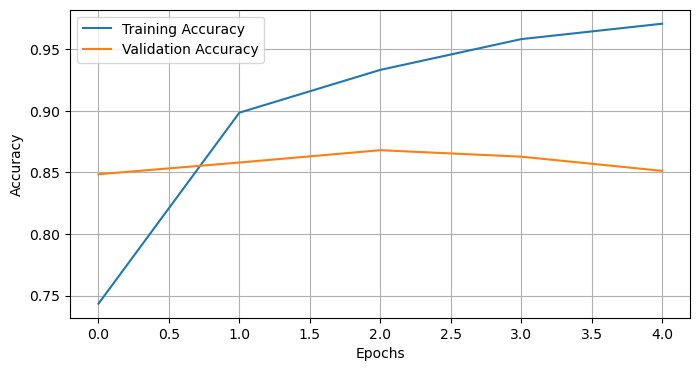

In [86]:
plt.figure(figsize = (8,4))
plt.plot(BiLSTM_history.history['accuracy'] , label = 'Training Accuracy')
plt.plot(BiLSTM_history.history['val_accuracy'] , label = 'Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

# BiGRU Model:-

C:\Users\windows 10\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 121s 851ms/step - accuracy: 0.7429 - loss: 0.4962 - val_accuracy: 0.8555 - val_loss: 0.3610
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 107s 861ms/step - accuracy: 0.8976 - loss: 0.2654 - val_accuracy: 0.8635 - val_loss: 0.3405
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 129s 757ms/step - accuracy: 0.9287 - loss: 0.1914 - val_accuracy: 0.8645 - val_loss: 0.3638
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 98s 782ms/step - accuracy: 0.9492 - loss: 0.1392 - val_accuracy: 0.8645 - val_loss: 0.3765
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 143s 785ms/step - accuracy: 0.9691 - loss: 0.0947 - val_accuracy: 0.8637 - val_loss: 0.3886
Final Trainig Accuracy :- 0.9690625071525574
The Final Validation Accuracy :- 0.8637499809265137


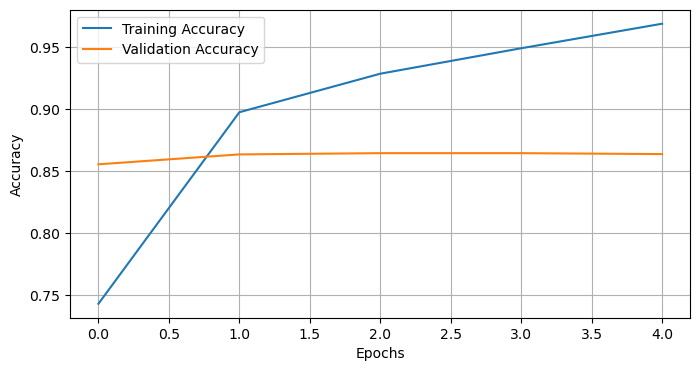

In [90]:
def create_BiGRU():
    model = Sequential([
        Embedding(input_dim = MAX_FEATURES , output_dim = 128 , input_length = MAX_LEN),
        Bidirectional(GRU(units = 64, return_sequences = True)),
        Dropout(0.4),
        Bidirectional(GRU(units = 64)),
        Dense(32 , activation = 'relu'),
        Dense(1, activation = 'sigmoid')
    ])
    return model
BiGRU_model = create_BiGRU()
BiGRU_model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

BiGRU_history = BiGRU_model.fit(
    x_train , y_train,
    batch_size = 128,
    epochs = 5,
    validation_split = 0.2
)

final_train_acc_BiGRU = BiGRU_history.history['accuracy'][-1]
print(f'Final Trainig Accuracy :- {final_train_acc_BiGRU}')
final_val_acc_BiGRU = BiGRU_history.history['val_accuracy'][-1]
print(f'The Final Validation Accuracy :- {final_val_acc_BiGRU}')

plt.figure(figsize = (8,4))
plt.plot(BiGRU_history.history['accuracy'] , label = 'Training Accuracy')
plt.plot(BiGRU_history.history['val_accuracy'] , label = 'Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()